# Giant Fiber の loom シミュレーション

`scripts/extract_gf_loom.py` が書いた `data/malecns/gf-loom/` を使い、接近する物体（loom）から巨大線維 DNp01 までの応答を見る。確認したいのは次の 2 つ。

- 刺激をどの細胞に、どういう波形で入れるか
- この回路を 1 ms 刻みで回したときの計算量

逃避の指令は DNp01 の最初のスパイクとする。TTMn（跳躍）と PSI（飛翔開始）は化学シナプスが小さく、実際の駆動は電気シナプスなので、ここには入れない。電気シナプスはこのデータに無い。

これは計測にフィットしたモデルではない。結合の本数だけが connectome から来ていて、発火率への変換と閾値は下の定数で選べる。


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.feather as feather
from matplotlib import font_manager

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "malecns" / "gf-loom" / "neurons.feather").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "malecns" / "gf-loom"
neurons = feather.read_table(DATA / "neurons.feather").to_pandas()
edges = feather.read_table(DATA / "edges.feather").to_pandas()
print(f"neurons {len(neurons)}  edges {len(edges)}  from {DATA}")


neurons 327  edges 20684  from /home/nobu/Git/fly-car/data/malecns/gf-loom


## 回路の中身

刺激を入れるのは LC4 と LPLC2、積分するのは同側の DNp01 だけにする。VPN 同士の結合は興奮性（アセチルコリン）で、この切り出しにはそれを抑える抑制細胞が無い。再帰ごとシミュレートすると発火が広がるので、VPN の発火率は loom から直接与える。


In [4]:
vpn = neurons.loc[neurons.role == "loom_vpn", ["bodyId", "type", "side"]].rename(
    columns={"bodyId": "body_pre", "side": "side_pre"}
)
gf = neurons.loc[neurons.role == "giant_fiber", ["bodyId", "side", "instance"]].rename(
    columns={"bodyId": "body_post", "side": "side_post", "instance": "gf_instance"}
)
feedforward = edges.merge(vpn, on="body_pre").merge(gf, on="body_post")

if not (feedforward.side_pre == feedforward.side_post).all():
    raise RuntimeError("対側への LC4/LPLC2 → DNp01 結合がある。想定と違う。")
if not feedforward.nt_sign.eq(1).all():
    raise RuntimeError("順方向結合にアセチルコリン以外がある。符号の扱いを見直す。")

counts = (
    neurons.groupby(["role", "type", "side"], observed=True)
    .size()
    .rename("neurons")
    .reset_index()
)
print(counts.to_string(index=False))

by_side = (
    feedforward.groupby(["type", "side_pre"], observed=True)
    .agg(edges=("weight", "size"), synapses=("weight", "sum"), median=("weight", "median"))
    .reset_index()
)
print("\nLC4/LPLC2 → 同側 DNp01")
print(by_side.to_string(index=False))

side_total = {
    side: int(feedforward.loc[feedforward.side_post == side, "weight"].sum())
    for side in ("L", "R")
}
print(f"\n同側への化学シナプス合計  左 {side_total['L']}  右 {side_total['R']}")
print(
    "重み 5 未満の順方向辺は"
    f" {int((feedforward.weight < 5).sum())} 本、"
    f"シナプス {int(feedforward.loc[feedforward.weight < 5, 'weight'].sum())} 個。"
    " ここからは落とさない。"
)

typed = edges.copy()
typed["type_pre"] = typed.body_pre.map(neurons.set_index("bodyId").type)
typed["type_post"] = typed.body_post.map(neurons.set_index("bodyId").type)


def synapse_sum(type_pre, type_post):
    mask = (typed.type_pre == type_pre) & (typed.type_post == type_post)
    return int(typed.loc[mask, "weight"].sum())


print("\n興奮性の再帰と、巨大線維への順方向（化学シナプス数）")
for source in ("LC4", "LPLC2"):
    recurrent = synapse_sum(source, source)
    onto_gf = synapse_sum(source, "DNp01")
    print(f"  {source:5}  自分同士 {recurrent:6}    → DNp01 {onto_gf:5}")

motor = neurons.loc[neurons.type.isin(["DNp01", "TTMn", "PSI"]), ["bodyId", "type", "instance"]]
motor_edges = edges.merge(
    motor.rename(columns={"bodyId": "body_pre", "type": "type_pre", "instance": "pre"}),
    on="body_pre",
).merge(
    motor.rename(columns={"bodyId": "body_post", "type": "type_post", "instance": "post"}),
    on="body_post",
)
motor_edges = motor_edges[motor_edges.type_pre == "DNp01"]
print("\nDNp01 からの化学シナプス。TTMn と PSI は小さく、対側の DNp01 は 1 個。電気シナプスはここには無い。")
print(
    motor_edges.groupby(["pre", "post"], observed=True)["weight"]
    .sum()
    .rename("synapses")
    .reset_index()
    .to_string(index=False)
)


          role      type side  neurons
  flight_motor DLMn a, b    L        1
  flight_motor DLMn a, b    R        1
  flight_motor  DLMn c-f    L        4
  flight_motor  DLMn c-f    R        4
flight_trigger       PSI    L        1
flight_trigger       PSI    R        1
   giant_fiber     DNp01    L        1
   giant_fiber     DNp01    R        1
    jump_motor      TTMn    L        1
    jump_motor      TTMn    R        1
      loom_vpn       LC4    L       71
      loom_vpn       LC4    R       55
      loom_vpn     LPLC2    L       94
      loom_vpn     LPLC2    R       91

LC4/LPLC2 → 同側 DNp01
 type side_pre  edges  synapses  median
  LC4        L     71      3782    53.0
  LC4        R     55      2580    47.0
LPLC2        L     94      2642    28.5
LPLC2        R     91      2220    21.0

同側への化学シナプス合計  左 6424  右 4800
重み 5 未満の順方向辺は 9 本、シナプス 26 個。 ここからは落とさない。

興奮性の再帰と、巨大線維への順方向（化学シナプス数）
  LC4    自分同士  18392    → DNp01  6362
  LPLC2  自分同士  46178    → DNp01  4862

DNp01 からの化学シナプス。T

## モデル

接近物体の視角は、半サイズを接近速度で割った $l/\lvert v\rvert$ と、衝突までの時間 $\tau$ で決まる。

$$
\theta(\tau) = 2 \arctan\frac{l/\lvert v\rvert}{\tau}, \qquad
\dot\theta = \frac{2\, l/\lvert v\rvert}{\tau^2 + (l/\lvert v\rvert)^2}
$$

視角が 90° になったところで刺激を止める。衝突時刻まで進めると視角が 180°、拡大速度が無限大になるため。$l/\lvert v\rvert = 20\,\mathrm{ms}$ のとき、打ち切り時点の拡大速度は 50 rad/s。

その拡大速度を、刺激する細胞ぜんぶに同じ発火率として入れる。列番号が無いので、視野のどこに物体があるかは指定できない。

$$
r(t) = R_{\mathrm{max}}\, \mathrm{clip}(\dot\theta / \dot\theta_{\mathrm{sat}},\, 0,\, 1)
$$

DNp01 への電流は、選んだ細胞の化学シナプス数を基準の合計で割り、発火率を $R_{\mathrm{ref}}$ で割ったもの。基準をその側の LC4+LPLC2 全体にすると、片眼の全細胞が $R_{\mathrm{ref}}$ で発火しているとき電流は 1。左右の巨大線維は別々に積分する。膜電位の平衡は電流そのものなので、1 が閾値。

$$
I = \frac{W_{\mathrm{selected}}}{W_{\mathrm{ref}}} \cdot \frac{r}{R_{\mathrm{ref}}}, \qquad
\tau_m \dot v = -v + I
$$

$v$ が 1 に達したらスパイクを 1 つ出して 0 に戻し、5 ms は入力を無視する。


In [5]:
# 発火率と閾値。結合の比率とは独立に変えられる。
R_MAX = 80.0            # Hz。拡大速度が飽和したときの VPN 発火率
THETA_DOT_SAT = 50.0    # rad/s。この拡大速度で発火率が R_MAX に達する
R_REF = 50.0            # Hz。片眼の全 VPN がこの発火率のとき電流が 1
TAU_MS = 5.0            # 巨大線維の膜時定数
V_THRESHOLD = 1.0
REFRAC_MS = 5.0
DT = 0.001              # s
T_BEFORE = 0.30         # 視角 90° の何秒前から
T_AFTER = 0.04
THETA_MAX = np.pi / 2   # 90°


def time_grid():
    n_before = int(round(T_BEFORE / DT))
    n_after = int(round(T_AFTER / DT))
    return np.arange(-n_before, n_after + 1) * DT


def loom_waveform(length_over_speed_s, time_s):
    """Return angular size (rad) and its derivative (rad/s). Both are 0 after the 90° cutoff."""
    tau_end = length_over_speed_s / np.tan(THETA_MAX / 2)
    tau = tau_end - time_s
    active = time_s <= 0
    theta = np.zeros_like(time_s)
    theta_dot = np.zeros_like(time_s)
    theta[active] = 2 * np.arctan(length_over_speed_s / tau[active])
    theta_dot[active] = 2 * length_over_speed_s / (tau[active] ** 2 + length_over_speed_s ** 2)
    return theta, theta_dot


def expansion_to_rate(theta_dot):
    return np.clip(theta_dot / THETA_DOT_SAT, 0.0, 1.0) * R_MAX


def lif(current):
    """Current-based LIF. `current` is in threshold units, one sample per DT."""
    voltage = np.empty(len(current))
    spiked = np.zeros(len(current), dtype=bool)
    v = 0.0
    silent_until = 0
    refrac_steps = int(round(REFRAC_MS / (DT * 1000)))
    step = (DT * 1000) / TAU_MS
    for i, drive in enumerate(current):
        if i < silent_until:
            v = 0.0
            voltage[i] = v
            continue
        v += step * (-v + drive)
        if v >= V_THRESHOLD:
            voltage[i] = V_THRESHOLD
            spiked[i] = True
            v = 0.0
            silent_until = i + refrac_steps
        else:
            voltage[i] = v
    return voltage, spiked


def spike_text(time_s, spiked):
    times = time_s[spiked] * 1000
    if len(times) == 0:
        return "—"
    return ", ".join(f"{t:.0f}" for t in times)


TIME_S = time_grid()


## 刺激の比較

どの細胞に同じ loom を入れるかを変える。電流の比はシナプス数の比そのもので、上の定数ではスケールが変わるだけ。

- 両方: 刺激側の LC4 と LPLC2 すべて
- LC4 のみ、LPLC2 のみ
- 上位 25%: その側で DNp01 へのシナプスが多い細胞の四分の一。視野の位置ではなく、結合が強い細胞だけを動かしたときの代理
- 基準「側ごと」: 左右をそれぞれのシナプス合計で正規化する。トレース数の左右差をキャンセルする
- 基準「左の合計」: 右も左の合計で割る。右の LC4 が少ないことをそのまま電流に残す


In [6]:
EXPERIMENTS = [
    {"id": "fast_left", "label": "速い・左・両方", "l_over_v_ms": 20, "sides": ("L",), "types": ("LC4", "LPLC2"), "top_frac": None, "ref": "side"},
    {"id": "fast_right", "label": "速い・右・両方", "l_over_v_ms": 20, "sides": ("R",), "types": ("LC4", "LPLC2"), "top_frac": None, "ref": "side"},
    {"id": "fast_both", "label": "速い・両眼・両方", "l_over_v_ms": 20, "sides": ("L", "R"), "types": ("LC4", "LPLC2"), "top_frac": None, "ref": "side"},
    {"id": "mid_left", "label": "中速・左・両方", "l_over_v_ms": 40, "sides": ("L",), "types": ("LC4", "LPLC2"), "top_frac": None, "ref": "side"},
    {"id": "slow_left", "label": "遅い・左・両方", "l_over_v_ms": 80, "sides": ("L",), "types": ("LC4", "LPLC2"), "top_frac": None, "ref": "side"},
    {"id": "fast_lc4", "label": "速い・左・LC4", "l_over_v_ms": 20, "sides": ("L",), "types": ("LC4",), "top_frac": None, "ref": "side"},
    {"id": "fast_lplc2", "label": "速い・左・LPLC2", "l_over_v_ms": 20, "sides": ("L",), "types": ("LPLC2",), "top_frac": None, "ref": "side"},
    {"id": "fast_top", "label": "速い・左・上位25%", "l_over_v_ms": 20, "sides": ("L",), "types": ("LC4", "LPLC2"), "top_frac": 0.25, "ref": "side"},
    {"id": "fast_right_raw", "label": "速い・右・左基準", "l_over_v_ms": 20, "sides": ("R",), "types": ("LC4", "LPLC2"), "top_frac": None, "ref": "left"},
]


def select_edges(side, types, top_frac):
    part = feedforward[(feedforward.side_post == side) & (feedforward.type.isin(types))]
    if top_frac is None:
        return part
    n_keep = max(1, int(round(len(part) * top_frac)))
    return part.nlargest(n_keep, "weight")


def reference_weight(side, mode):
    if mode == "side":
        return float(side_total[side])
    if mode == "left":
        return float(side_total["L"])
    raise ValueError(mode)


def run_experiment(spec):
    theta, theta_dot = loom_waveform(spec["l_over_v_ms"] / 1000, TIME_S)
    rate = expansion_to_rate(theta_dot)
    current = np.zeros((len(TIME_S), 2))
    selected_synapses = {}
    for index, side in enumerate(("L", "R")):
        if side not in spec["sides"]:
            selected_synapses[side] = 0
            continue
        part = select_edges(side, spec["types"], spec["top_frac"])
        selected_synapses[side] = int(part.weight.sum())
        ref = reference_weight(side, spec["ref"])
        # I = (sum of selected synapse counts) / W_ref * r / R_ref
        current[:, index] = (selected_synapses[side] / ref) * (rate / R_REF)
    voltage = np.zeros_like(current)
    spiked = np.zeros_like(current, dtype=bool)
    for index in (0, 1):
        voltage[:, index], spiked[:, index] = lif(current[:, index])
    return {
        "theta": theta,
        "theta_dot": theta_dot,
        "rate": rate,
        "current": current,
        "voltage": voltage,
        "spiked": spiked,
        "synapses": selected_synapses,
    }


results = {spec["id"]: run_experiment(spec) for spec in EXPERIMENTS}

# 閉形式と、辺を 1 本ずつ足すループが一致するか。移植するカーネルは後者。
check = select_edges("L", ("LC4", "LPLC2"), None)
weights = [float(w) for w in check.weight.to_numpy()]
ref = float(side_total["L"])
rate = results["fast_left"]["rate"]
loop_current = np.empty_like(rate)
for i, r in enumerate(rate):
    total = 0.0
    for w in weights:
        total += r * w
    loop_current[i] = total / ref / R_REF
err = float(np.max(np.abs(loop_current - results["fast_left"]["current"][:, 0])))
print(f"辺ごとの積和と閉形式の最大差 {err:.3e}")

rows = []
for spec in EXPERIMENTS:
    out = results[spec["id"]]
    own = {
        side: (out["synapses"][side] / side_total[side] if side in spec["sides"] else 0.0)
        for side in ("L", "R")
    }
    rows.append(
        {
            "条件": spec["label"],
            "l/|v| ms": spec["l_over_v_ms"],
            "基準": "側ごと" if spec["ref"] == "side" else "左の合計",
            "その側を使う割合": max(own.values()),
            "I 左": out["current"][:, 0].max(),
            "I 右": out["current"][:, 1].max(),
            "発火 左 ms": spike_text(TIME_S, out["spiked"][:, 0]),
            "発火 右 ms": spike_text(TIME_S, out["spiked"][:, 1]),
        }
    )
table = pd.DataFrame(rows)
print(table.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


辺ごとの積和と閉形式の最大差 6.661e-16
        条件  l/|v| ms   基準  その側を使う割合   I 左   I 右 発火 左 ms 発火 右 ms
   速い・左・両方        20  側ごと     1.000 1.600 0.000      -6       —
   速い・右・両方        20  側ごと     1.000 0.000 1.600       —      -6
  速い・両眼・両方        20  側ごと     1.000 1.600 1.600      -6      -6
   中速・左・両方        40  側ごと     1.000 0.800 0.000       —       —
   遅い・左・両方        80  側ごと     1.000 0.400 0.000       —       —
  速い・左・LC4        20  側ごと     0.589 0.942 0.000       —       —
速い・左・LPLC2        20  側ごと     0.411 0.658 0.000       —       —
速い・左・上位25%        20  側ごと     0.395 0.632 0.000       —       —
  速い・右・左基準        20 左の合計     1.000 0.000 1.196       —       0


## 図

時刻 0 は視角が 90° に達して刺激を切った時点。負の時刻が接近中。


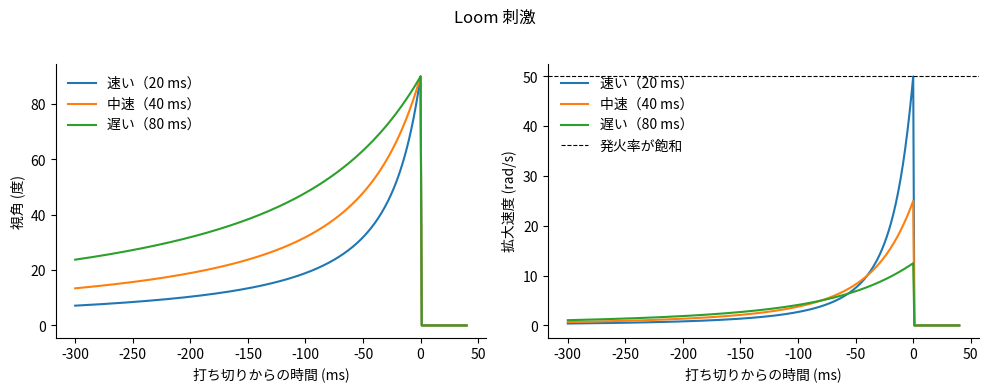

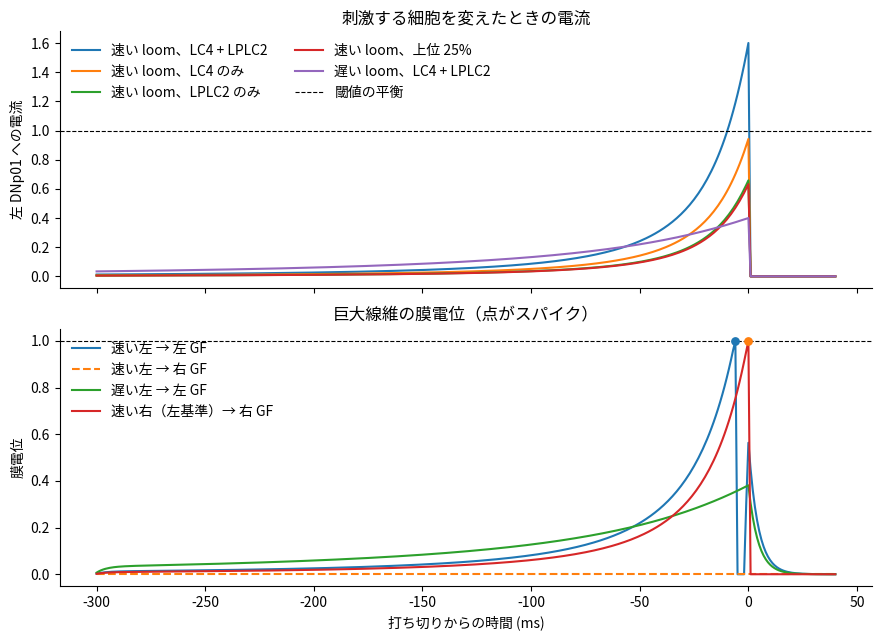

In [7]:
for candidate in (
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJKjp-Regular.otf",
):
    if Path(candidate).exists():
        font_manager.fontManager.addfont(candidate)
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=candidate).get_name()
        break
else:
    print("日本語フォントが無いので、図のラベルは既定フォントになる。")
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
loom_speed = {20: "速い", 40: "中速", 80: "遅い"}
for l_over_v_ms in (20, 40, 80):
    theta, theta_dot = loom_waveform(l_over_v_ms / 1000, TIME_S)
    label = f"{loom_speed[l_over_v_ms]}（{l_over_v_ms} ms）"
    axes[0].plot(TIME_S * 1000, np.rad2deg(theta), label=label)
    axes[1].plot(TIME_S * 1000, theta_dot, label=label)
axes[1].axhline(THETA_DOT_SAT, color="black", lw=0.8, ls="--", label="発火率が飽和")
axes[0].set_ylabel("視角 (度)")
axes[1].set_ylabel("拡大速度 (rad/s)")
for ax in axes:
    ax.set_xlabel("打ち切りからの時間 (ms)")
    ax.legend(loc="upper left", frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.suptitle("Loom 刺激", y=1.02)
fig.tight_layout()

current_lines = (
    ("fast_left", "速い loom、LC4 + LPLC2"),
    ("fast_lc4", "速い loom、LC4 のみ"),
    ("fast_lplc2", "速い loom、LPLC2 のみ"),
    ("fast_top", "速い loom、上位 25%"),
    ("slow_left", "遅い loom、LC4 + LPLC2"),
)
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
for key, label in current_lines:
    axes[0].plot(TIME_S * 1000, results[key]["current"][:, 0], label=label)
axes[0].axhline(1.0, color="black", lw=0.8, ls="--", label="閾値の平衡")
axes[0].set_ylabel("左 DNp01 への電流")
axes[0].legend(loc="upper left", frameon=False, ncol=2)
axes[0].set_title("刺激する細胞を変えたときの電流")

voltage_lines = (
    ("fast_left", 0, "速い左 → 左 GF", "-"),
    ("fast_left", 1, "速い左 → 右 GF", "--"),
    ("slow_left", 0, "遅い左 → 左 GF", "-"),
    ("fast_right_raw", 1, "速い右（左基準）→ 右 GF", "-"),
)
for key, index, label, style in voltage_lines:
    axes[1].plot(TIME_S * 1000, results[key]["voltage"][:, index], ls=style, label=label)
    spike_at = TIME_S[results[key]["spiked"][:, index]] * 1000
    if len(spike_at):
        axes[1].scatter(spike_at, np.ones_like(spike_at), s=28, zorder=3)
axes[1].axhline(1.0, color="black", lw=0.8, ls="--")
axes[1].set_ylabel("膜電位")
axes[1].set_xlabel("打ち切りからの時間 (ms)")
axes[1].legend(loc="upper left", frameon=False)
axes[1].set_title("巨大線維の膜電位（点がスパイク）")
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()


## 計算量

移植する中身は、刺激中の発火率を順方向の辺へ掛けて DNp01 に足すループ。辺の数は LC4 と LPLC2 から同側の DNp01 への本数だけで、再帰や運動ニューロンは含まない。比較として、切り出した化学結合を全部足す 1 ステップも計る。

CPython の時間はインタプリタのオーバーヘッドが大きい。Arduino Uno Q に載せるときの量は、こちらの経過時間ではなく、1 ステップの積和回数で見る。


In [8]:
import time

feed_weights = [float(w) for w in feedforward.weight.to_numpy()]
n_feed = len(feed_weights)


def feedforward_step(rate):
    total = 0.0
    for w in feed_weights:
        total += rate * w
    return total


repeats = 300
started = time.perf_counter()
for _ in range(repeats):
    for r in results["fast_left"]["rate"]:
        feedforward_step(r)
elapsed = time.perf_counter() - started
steps = repeats * len(TIME_S)
print(f"順方向の辺 {n_feed} 本")
print(f"CPython で 1 ステップ {elapsed / steps * 1e6:.1f} µs（{steps} ステップの平均）")
print(f"1 ms 刻みに必要な積和は毎秒 {n_feed * 1000:,} 回")

ids = np.sort(neurons.bodyId.to_numpy())
pre = np.searchsorted(ids, edges.body_pre.to_numpy())
post = np.searchsorted(ids, edges.body_post.to_numpy())
weight = edges.weight.to_numpy().astype(np.float64)
rate_all = np.zeros(len(ids))
vpn_index = np.searchsorted(ids, vpn.body_pre.to_numpy())
rate_all[vpn_index] = R_MAX
started = time.perf_counter()
full_repeats = 200
for _ in range(full_repeats):
    accum = np.zeros(len(ids))
    np.add.at(accum, post, rate_all[pre] * weight)
elapsed = time.perf_counter() - started
print(f"\n切り出し全体の辺 {len(edges):,} 本")
print(f"numpy で 1 ステップ {elapsed / full_repeats * 1e6:.1f} µs（{full_repeats} 回の平均）")
print(f"1 ms 刻みに必要な積和は毎秒 {len(edges) * 1000:,} 回")
print(f"試行 1 回の長さは {len(TIME_S)} ステップ（{len(TIME_S) * DT * 1000:.0f} ms）")


順方向の辺 311 本
CPython で 1 ステップ 33.6 µs（102300 ステップの平均）
1 ms 刻みに必要な積和は毎秒 311,000 回

切り出し全体の辺 20,684 本
numpy で 1 ステップ 65.0 µs（200 回の平均）
1 ms 刻みに必要な積和は毎秒 20,684,000 回
試行 1 回の長さは 341 ステップ（341 ms）


## 読み方

電流の左右と細胞種の差は、定数を変えても比率は動かない。左の DNp01 では化学シナプスの約 6 割が LC4、約 4 割が LPLC2 から来ている。同じ発火率を入れると電流もこの比になる。シナプス数の多い細胞を 25% だけ動かしても、残る電流は全体の約 4 割で、片眼ぜんぶの代わりにはならない。

発火するかは閾値の置き方による。今の定数では、速い loom（$l/\lvert v\rvert = 20\,\mathrm{ms}$）で片眼の LC4 と LPLC2 を両方動かしたとき、同側の DNp01 が打ち切りの数 ms 前に 1 回発火する。反対側は電流が 0 のまま。遅い loom と、片方の細胞種だけでは閾値に届かない。ただし LC4 だけでもピークは閾値のすぐ下まで来る。`R_MAX` を上げるか `R_REF` を下げると、LC4 だけでも発火する。LPLC2 だけではそこまで届かない。

右眼を、左のシナプス合計を基準にして駆動すると、ピーク電流は 1.60 ではなく約 1.20 になり、スパイクは打ち切りの瞬間まで遅れる。右の LC4 の記載が 55 対 71 と少ないためで、右眼が生物学的に弱いという意味ではない。左右を分けて正規化すれば、同じ刺激は左右で同じ電流、同じ発火時刻になる。

ロボットの逃避指令には、最初のスパイクを使う。この細胞には順応を入れておらず、電流が閾値より上に長く居座ると不応期ごとに撃ち続ける。今回の速い loom はピークが短いので 1 回で終わっている。

変える場所は、パラメータのセルの `R_MAX`、`THETA_DOT_SAT`、`R_REF`、`TAU_MS` と、`EXPERIMENTS` のリスト。
